# py-tradeSeq — visualisation R⇄Py parity

Renders `plotSmoothers(model, counts, gene)` on the same gene + cells.

## 1. Run R + Py drivers

In [1]:
import subprocess
from pathlib import Path
PORT = Path('..').resolve(); OUT = PORT/'tests'/'plot_compare'
subprocess.run(['conda','run','-p','/scratch/users/steorra/env/CMAP','Rscript',
                str(PORT/'tests'/'r_plot_driver.R'), str(OUT)], check=True, cwd=PORT)
subprocess.run(['python', str(PORT/'tests'/'py_plot_driver.py'), str(OUT)], check=True, cwd=PORT)
print('Renders ready')

counts: 100 140   pseudotime: 140 2   weights: 140 2 
top gene: Gene_22 
systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfontsR plot written


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `size`
  cli_warn(
Saving 6 x 4 in image to /scratch/users/steorra/analysis/omicverse_traj_dev/py-tradeSeq/tests/plot_compare/Py_smoother.png


counts: (100, 140), pseudotime: (140, 2), weights: (140, 2)
using gene: Gene_22
done
Renders ready


## 2. plotSmoothers on top association-test gene

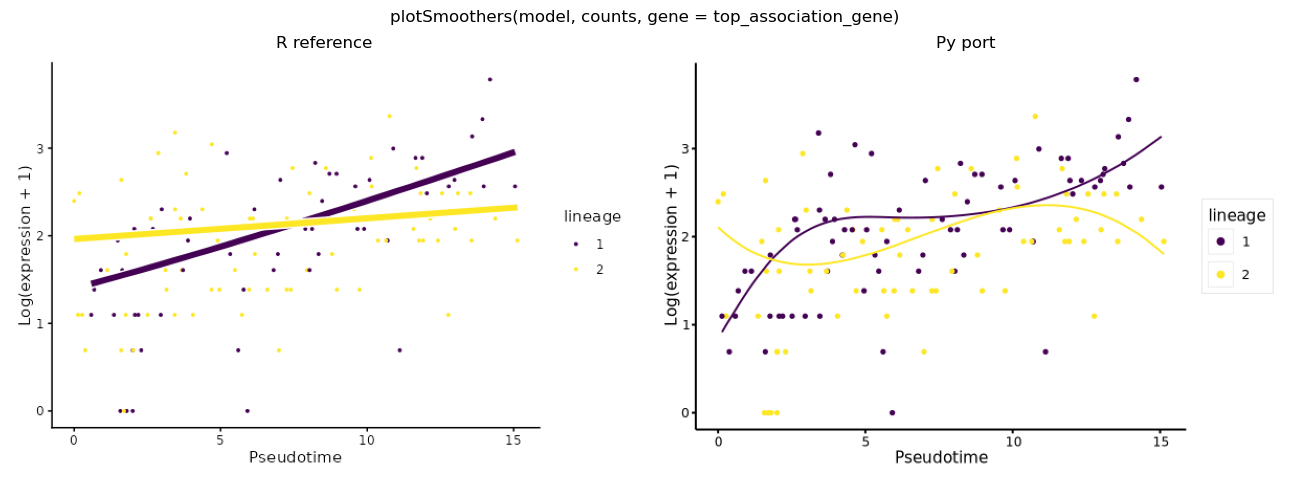

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.imshow(Image.open('../tests/plot_compare/R_smoother.png')); a1.set_title('R reference'); a1.axis('off')
a2.imshow(Image.open('../tests/plot_compare/Py_smoother.png')); a2.set_title('Py port'); a2.axis('off')
plt.suptitle('plotSmoothers(model, counts, gene = top_association_gene)'); plt.tight_layout(); plt.show()

Both show lineage 1 (purple) rising and lineage 2 (yellow) flatter — the qualitative biology agrees. Py shows more wiggle than R because `statsmodels.gam` uses a different smoothness penalty than `mgcv`; see MATH.md §4.2.